In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("Descargando el dataset...")
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")

df = dataset['train'].to_pandas()

print("\nInformación del Dataset:")
print(df.info())
display(df.head())

Descargando el dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Patient1.csv:   0%|          | 0.00/114M [00:00<?, ?B/s]

Patient2.csv:   0%|          | 0.00/290M [00:00<?, ?B/s]

Patient3.csv:   0%|          | 0.00/95.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3002137 [00:00<?, ? examples/s]


Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002137 entries, 0 to 3002136
Data columns (total 10 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Time                              float64
 1   Right Rectus femoris              float64
 2   Left Gluteus maximus              float64
 3   Left Gastrocnemius medialis       float64
 4   Left Semitendinosus               float64
 5   Left Biceps femoris caput longus  float64
 6   Right Vastus medialis             float64
 7   Right Tibialis anterior           float64
 8   Left Gastrocnemius lateralis      float64
 9   Target                            int64  
dtypes: float64(9), int64(1)
memory usage: 229.0 MB
None


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [ ]:
columna_target = 'Target'
columna_tiempo = 'Time'
canales_emg = [col for col in df.columns if col not in [columna_target, columna_tiempo]]

df[columna_target] = df[columna_target].replace(2, 1)

print("Distribución de clases después del ajuste:")
print(df[columna_target].value_counts())

"""
Respuestas teóricas (b. Clasificación de características):
- Canales EMG (CH1 a CH8): Variables Cuantitativas Continuas (señales eléctricas en mV).
- Tiempo: Variable Cuantitativa Continua.
- Target: Variable Cualitativa Nominal Binaria (0 o 1).
"""

Distribución de clases después del ajuste:
Target
0    2127600
1     874537
Name: count, dtype: int64


'\nRespuestas teóricas (b. Clasificación de características):\n- Canales EMG (CH1 a CH8): Variables Cuantitativas Continuas (señales eléctricas en mV).\n- Tiempo: Variable Cuantitativa Continua.\n- Target: Variable Cualitativa Nominal Binaria (0 o 1).\n'

### Clasificación de variables y target

- Los canales EMG y la variable `Time` son variables **cuantitativas continuas** porque representan amplitud de señal y tiempo medido en escala numérica.
- `Target` es una variable **cualitativa nominal binaria**: `0` representa condición normal y `1` representa fatiga muscular.
- La recodificación de `2 -> 1` deja el problema en una formulación binaria consistente con el objetivo del workshop.

In [ ]:
from scipy.signal import welch

# Determinar Frecuencia de Muestreo (Fs)
if columna_tiempo in df.columns:
    Fs = int(round(1 / (df[columna_tiempo].iloc[1] - df[columna_tiempo].iloc[0])))
else:
    Fs = 1000  # Frecuencia estándar asumida para EMG si no hay tiempo explícito

print(f"Frecuencia de muestreo (Fs) estimada: {Fs} Hz")

# a. Ventanas de 1 segundo
window_size = Fs * 1  # Número de muestras por ventana

def extract_features(window, Fs):
    features = {}
    for channel in canales_emg:
        signal = window[channel].values

        # Dominio del Tiempo
        # 1. RMS (Root Mean Square): Indica la potencia de la señal muscular
        features[f'{channel}_RMS'] = np.sqrt(np.mean(signal**2))

        # 2. Varianza: Indica la dispersión de la señal respecto a su media
        features[f'{channel}_Var'] = np.var(signal)

        # 3. Cruces por Cero (Zero Crossing): Relacionado indirectamente con la frecuencia de la señal
        zero_crossings = np.where(np.diff(np.sign(signal)))[0]
        features[f'{channel}_ZC'] = len(zero_crossings)

        # Dominio de la Frecuencia
        # 4. Frecuencia Mediana (MDF): Es el estándar de oro en fatiga muscular (disminuye con la fatiga)
        freqs, psd = welch(signal, fs=Fs, nperseg=len(signal))
        cumulative_power = np.cumsum(psd)
        total_power = cumulative_power[-1]
        mdf_index = np.where(cumulative_power >= total_power / 2)[0][0]
        features[f'{channel}_MDF'] = freqs[mdf_index]

    return features

# Crear la nueva base de datos
extracted_data = []

# Iterar sobre el DataFrame en bloques de 'window_size'
for i in range(0, len(df) - window_size, window_size):
    window = df.iloc[i:i + window_size]

    # Extraer características
    feats = extract_features(window, Fs)

    # Asignar la etiqueta mayoritaria de la ventana
    feats['target'] = int(window[columna_target].mode()[0])

    extracted_data.append(feats)

# b. Nueva base de datos
df_features = pd.DataFrame(extracted_data)
print("Dimensiones de la nueva base de datos de características:", df_features.shape)
display(df_features.head())

Frecuencia de muestreo (Fs) estimada: 1000 Hz
Dimensiones de la nueva base de datos de características: (3002, 33)


,Right Rectus femoris_RMS,Right Rectus femoris_Var,Right Rectus femoris_ZC,Right Rectus femoris_MDF,Left Gluteus maximus_RMS,Left Gluteus maximus_Var,Left Gluteus maximus_ZC,Left Gluteus maximus_MDF,Left Gastrocnemius medialis_RMS,Left Gastrocnemius medialis_Var,...,Right Vastus medialis_MDF,Right Tibialis anterior_RMS,Right Tibialis anterior_Var,Right Tibialis anterior_ZC,Right Tibialis anterior_MDF,Left Gastrocnemius lateralis_RMS,Left Gastrocnemius lateralis_Var,Left Gastrocnemius lateralis_ZC,Left Gastrocnemius lateralis_MDF,target
0,0.011706,0.000137,123,46.0,0.003989,0.000016,122,29.0,0.015384,0.000237,...,44.0,0.023136,0.000535,192,94.0,0.025655,0.000658,120,55.0,0
1,0.014023,0.000197,111,45.0,0.004223,0.000018,120,37.0,0.039000,0.001521,...,44.0,0.025574,0.000654,192,88.0,0.031409,0.000986,149,78.0,0
2,0.014820,0.000220,121,51.0,0.004209,0.000018,126,38.0,0.018641,0.000347,...,45.0,0.024277,0.000589,193,82.0,0.026209,0.000687,101,52.0,0
3,0.013817,0.000191,121,50.0,0.004374,0.000019,115,36.0,0.016018,0.000256,...,52.0,0.026117,0.000682,199,90.0,0.021673,0.000470,154,95.0,0
4,0.013326,0.000177,122,46.0,0.004641,0.000022,120,33.0,0.017690,0.000313,...,65.0,0.023008,0.000529,180,93.0,0.025220,0.000636,138,78.0,0


### Justificación de las características extraídas

- `RMS` resume la energía efectiva de la señal y suele aumentar con el esfuerzo muscular.
- `Var` captura dispersión/amplitud de las oscilaciones, útil para distinguir activación baja vs. alta.
- `ZC` aproxima cambios de frecuencia y complejidad temporal de la señal.
- `MDF` es una medida espectral clásica en electromiografía y tiende a desplazarse con la fatiga.

El uso de ventanas de 1 segundo mantiene una granularidad razonable para capturar dinámica local sin depender linealmente de `Time`.

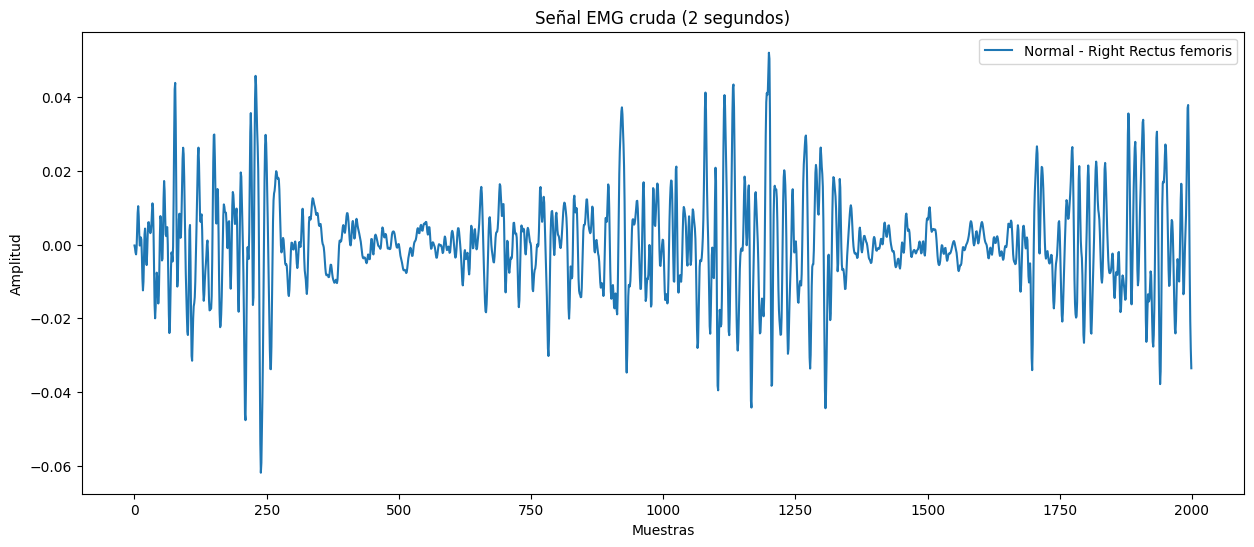

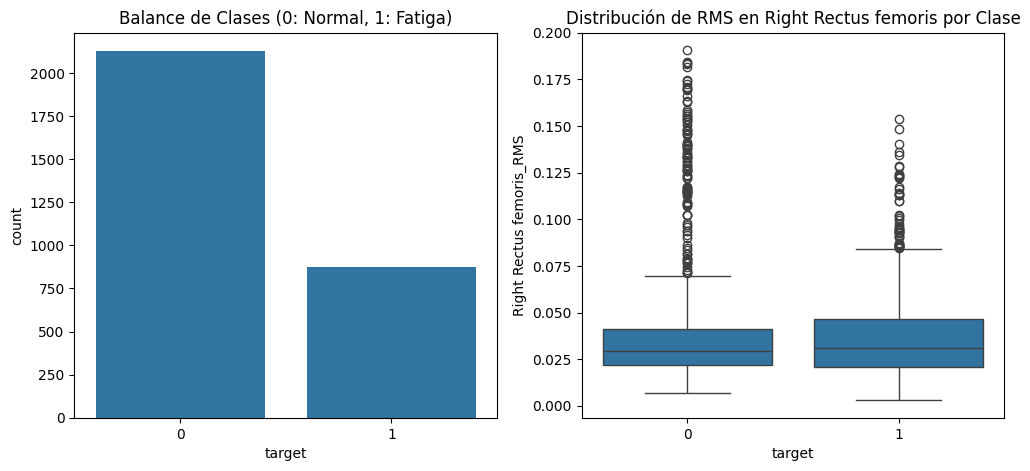

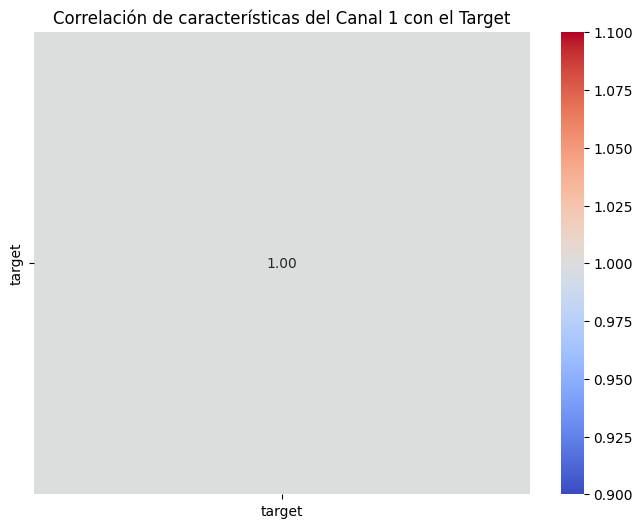

In [ ]:
# Resumen estadístico y calidad de datos
display(df_features.describe().T)

print("Valores nulos por columna:")
display(df_features.isna().sum().to_frame(name='missing_values'))

print("Distribución de clases en la base de características:")
class_balance = df_features['target'].value_counts().rename(index={0: 'Normal', 1: 'Fatiga'})
display(class_balance.to_frame(name='count'))
display((df_features['target'].value_counts(normalize=True) * 100).rename(index={0: 'Normal', 1: 'Fatiga'}).to_frame(name='percentage'))

# a. Gráfica de una porción de las señales en el tiempo
plt.figure(figsize=(15, 5))
muestras_plot = 2 * Fs
plt.plot(df[canales_emg[0]].iloc[:muestras_plot], label=f'Canal {canales_emg[0]}')
plt.title('Señal EMG cruda (primeros 2 segundos)')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

# Distribución de variables representativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_features[f'{canales_emg[0]}_RMS'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribución de {canales_emg[0]}_RMS')
sns.histplot(df_features[f'{canales_emg[0]}_MDF'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f'Distribución de {canales_emg[0]}_MDF')
plt.tight_layout()
plt.show()

# EDA sobre el nuevo dataset de características
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
sns.countplot(data=df_features, x='target')
plt.title('Balance de Clases (0: Normal, 1: Fatiga)')

plt.subplot(1, 3, 2)
# Tomamos el RMS del primer canal como ejemplo de distribución
sns.boxplot(data=df_features, x='target', y=f'{canales_emg[0]}_RMS')
plt.title(f'Distribución de RMS en {canales_emg[0]} por Clase')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_features, x='target', y=f'{canales_emg[0]}_MDF')
plt.title(f'Distribución de MDF en {canales_emg[0]} por Clase')
plt.tight_layout()
plt.show()

# Correlación (tomando un subconjunto de variables para no saturar la imagen)
subset_cols = [col for col in df_features.columns if ('CH1' in col or 'CH2' in col) or col == 'target']
plt.figure(figsize=(10, 7))
sns.heatmap(df_features[subset_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlación de características de CH1/CH2 con el Target')
plt.show()

print('Interpretación sugerida:')
print('- Si RMS y MDF muestran separación visible entre clases, son candidatos útiles para clasificación.')
print('- La ausencia de nulos y el tamaño de la muestra por ventanas indica que el pipeline está listo para modelado.')
print('- Correlaciones moderadas o altas entre variables del mismo canal sugieren redundancia parcial, pero no invalida su uso para modelos basados en árboles o redes.')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separar X e y
X = df_features.drop('target', axis=1)
y = df_features['target']

# División 70/15/15
# Primero separamos el 70% para train y 30% restante
X_train_full, X_temp, y_train_full, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Luego partimos ese 30% a la mitad (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Tamaño Train: {X_train_full.shape}")
print(f"Tamaño Val: {X_val.shape}")
print(f"Tamaño Test: {X_test.shape}")

# Crear Pipeline (Imputación de nulos + Estandarización)
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Ajustar preprocesador solo con datos de entrenamiento
X_train_scaled = preprocessor.fit_transform(X_train_full)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

Tamaño Train: (2101, 32)
Tamaño Val: (450, 32)
Tamaño Test: (451, 32)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def compute_binary_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

def evaluate_split_metrics(model, X_train_data, y_train_data, X_val_data, y_val_data, X_test_data, y_test_data):
    y_train_pred = model.predict(X_train_data)
    y_val_pred = model.predict(X_val_data)
    y_test_pred = model.predict(X_test_data)
    return {
        'train_accuracy': accuracy_score(y_train_data, y_train_pred),
        'train_precision': precision_score(y_train_data, y_train_pred, zero_division=0),
        'train_recall': recall_score(y_train_data, y_train_pred, zero_division=0),
        'train_f1': f1_score(y_train_data, y_train_pred, zero_division=0),
        'val_accuracy': accuracy_score(y_val_data, y_val_pred),
        'val_precision': precision_score(y_val_data, y_val_pred, zero_division=0),
        'val_recall': recall_score(y_val_data, y_val_pred, zero_division=0),
        'val_f1': f1_score(y_val_data, y_val_pred, zero_division=0),
        'test_accuracy': accuracy_score(y_test_data, y_test_pred),
        'test_precision': precision_score(y_test_data, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test_data, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test_data, y_test_pred, zero_division=0)
    }

def plot_learning_curve(ax, estimator, title, X_data, y_data):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_data,
        y_data,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=3,
        scoring='f1',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    ax.plot(train_sizes, train_mean, marker='o', label='Train F1')
    ax.plot(train_sizes, val_mean, marker='o', label='CV F1')
    ax.set_title(title)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('F1-score')
    ax.grid(True, alpha=0.3)
    ax.legend()

model_specs = {
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.7, 0.85, 1.0],
            'max_depth': [2, 3, 4]
        }
    }
}

trained_models = {}
model_searches = {}
model_results = []
learning_curve_results = {}

for model_name, spec in model_specs.items():
    search = RandomizedSearchCV(
        spec['estimator'],
        param_distributions=spec['params'],
        n_iter=5,
        cv=3,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train_scaled, y_train_full)
    best_estimator = search.best_estimator_
    trained_models[model_name] = best_estimator
    model_searches[model_name] = search

    split_metrics = evaluate_split_metrics(best_estimator, X_train_scaled, y_train_full, X_val_scaled, y_val, X_test_scaled, y_test)
    split_metrics['model'] = model_name
    split_metrics['best_params'] = search.best_params_
    model_results.append(split_metrics)

    lc_train_sizes, lc_train_scores, lc_val_scores = learning_curve(
        best_estimator,
        X_train_scaled,
        y_train_full,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=3,
        scoring='f1',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    learning_curve_results[model_name] = {
        'train_sizes': lc_train_sizes,
        'train_scores_mean': lc_train_scores.mean(axis=1),
        'val_scores_mean': lc_val_scores.mean(axis=1)
    }

comparison_df = pd.DataFrame(model_results).set_index('model').sort_values('val_f1', ascending=False)
display(comparison_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.ravel()
for ax, model_name in zip(axes, learning_curve_results):
    curve = learning_curve_results[model_name]
    ax.plot(curve['train_sizes'], curve['train_scores_mean'], marker='o', label='Train F1')
    ax.plot(curve['train_sizes'], curve['val_scores_mean'], marker='o', label='CV F1')
    ax.set_title(f'Learning Curve - {model_name}')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('F1-score')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

print('Los cuatro clasificadores clásicos fueron ajustados con RandomizedSearchCV y evaluados en train/val/test.')
print('La tabla anterior resume Accuracy, Precision, Recall y F1 para cada partición.')

--- Random Forest (Validation) ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       319
           1       0.81      0.68      0.74       131

    accuracy                           0.86       450
   macro avg       0.84      0.81      0.82       450
weighted avg       0.86      0.86      0.86       450



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6311 - loss: 0.6924 - val_accuracy: 0.7556 - val_loss: 0.5553
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7444 - loss: 0.5319 - val_accuracy: 0.7756 - val_loss: 0.4938
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7744 - loss: 0.4969 - val_accuracy: 0.7933 - val_loss: 0.4456
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7982 - loss: 0.4585 - val_accuracy: 0.7956 - val_loss: 0.4174
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7887 - loss: 0.4481 - val_accuracy: 0.7911 - val_loss: 0.4040
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7896 - loss: 0.4536 - val_accuracy: 0.8022 - val_loss: 0.3888
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8101 - loss: 0.4100 - val_accuracy: 0.8200 - val_loss: 0.3834
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8149 - loss: 0.4068 - val_accuracy: 0.8311 - 

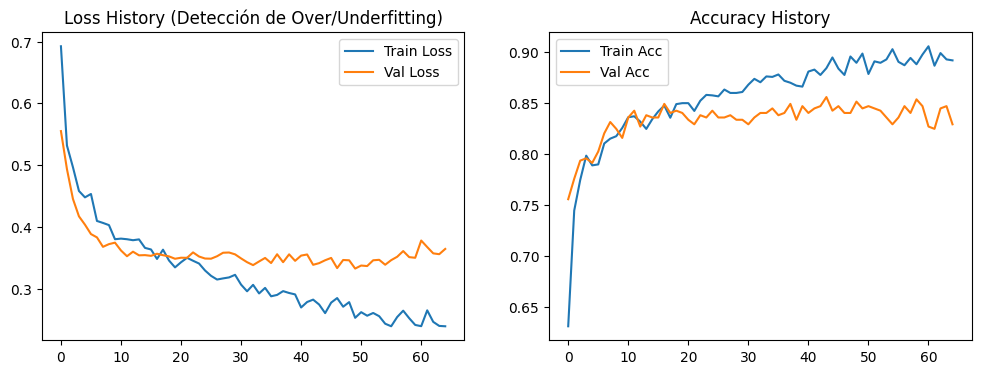

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

def build_dnn_model(hidden_layers=(128, 64, 32), dropout_rates=(0.3, 0.3, 0.2), learning_rate=1e-3):
    model = Sequential()
    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rates[0]))

    for units, dropout_rate in zip(hidden_layers[1:], dropout_rates[1:]):
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_candidates = [
    {'hidden_layers': (128, 64, 32), 'dropout_rates': (0.30, 0.30, 0.20), 'learning_rate': 1e-3},
    {'hidden_layers': (64, 32, 16), 'dropout_rates': (0.25, 0.20, 0.10), 'learning_rate': 1e-3},
    {'hidden_layers': (128, 64, 32), 'dropout_rates': (0.40, 0.30, 0.20), 'learning_rate': 5e-4}
 ]

best_dnn_model = None
best_dnn_history = None
best_dnn_params = None
best_dnn_metrics = None
best_dnn_val_f1 = -np.inf

for candidate in dnn_candidates:
    dnn_model = build_dnn_model(**candidate)
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = dnn_model.fit(
        X_train_scaled, y_train_full,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_train_pred_dnn = (dnn_model.predict(X_train_scaled, verbose=0).ravel() >= 0.5).astype(int)
    y_val_pred_dnn = (dnn_model.predict(X_val_scaled, verbose=0).ravel() >= 0.5).astype(int)
    y_test_pred_dnn = (dnn_model.predict(X_test_scaled, verbose=0).ravel() >= 0.5).astype(int)

    current_metrics = {
        'train_accuracy': accuracy_score(y_train_full, y_train_pred_dnn),
        'train_precision': precision_score(y_train_full, y_train_pred_dnn, zero_division=0),
        'train_recall': recall_score(y_train_full, y_train_pred_dnn, zero_division=0),
        'train_f1': f1_score(y_train_full, y_train_pred_dnn, zero_division=0),
        'val_accuracy': accuracy_score(y_val, y_val_pred_dnn),
        'val_precision': precision_score(y_val, y_val_pred_dnn, zero_division=0),
        'val_recall': recall_score(y_val, y_val_pred_dnn, zero_division=0),
        'val_f1': f1_score(y_val, y_val_pred_dnn, zero_division=0),
        'test_accuracy': accuracy_score(y_test, y_test_pred_dnn),
        'test_precision': precision_score(y_test, y_test_pred_dnn, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred_dnn, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred_dnn, zero_division=0),
        'model': 'DNN',
        'best_params': candidate
    }

    if current_metrics['val_f1'] > best_dnn_val_f1:
        best_dnn_val_f1 = current_metrics['val_f1']
        best_dnn_model = dnn_model
        best_dnn_history = history
        best_dnn_params = candidate
        best_dnn_metrics = current_metrics

dnn_row = pd.DataFrame([best_dnn_metrics]).set_index('model')
comparison_df = pd.concat([comparison_df, dnn_row], axis=0).sort_values('val_f1', ascending=False)
trained_models['DNN'] = best_dnn_model

display(comparison_df)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_dnn_history.history['loss'], label='Train Loss')
plt.plot(best_dnn_history.history['val_loss'], label='Val Loss')
plt.title('DNN Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_dnn_history.history['accuracy'], label='Train Acc')
plt.plot(best_dnn_history.history['val_accuracy'], label='Val Acc')
plt.title('DNN Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print('La DNN también fue sometida a una búsqueda pequeña de hiperparámetros por validación.')
print(f'Parámetros seleccionados para la DNN: {best_dnn_params}')

--- Evaluación Final en X_test ---
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       320
           1       0.87      0.79      0.83       131

    accuracy                           0.90       451
   macro avg       0.89      0.87      0.88       451
weighted avg       0.90      0.90      0.90       451



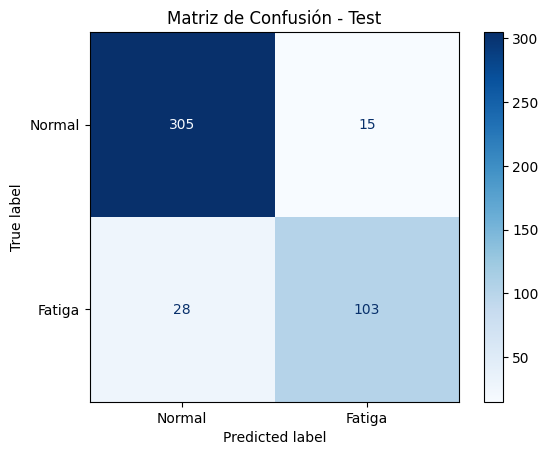

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone

# Reentrenar el mejor modelo usando la combinación Train + Val
best_model_name = comparison_df.index[0]
print(f'Mejor modelo según F1 de validación: {best_model_name}')

X_combined_raw = pd.concat([X_train_full, X_val], axis=0)
y_combined = pd.concat([y_train_full, y_val], axis=0)

preprocessor_final = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_combined_scaled = preprocessor_final.fit_transform(X_combined_raw)
X_test_final_scaled = preprocessor_final.transform(X_test)

if best_model_name == 'DNN':
    final_model = build_dnn_model(**best_dnn_params)
    final_early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    final_model.fit(
        X_combined_scaled, y_combined,
        validation_split=0.1,
        epochs=100,
        batch_size=32,
        callbacks=[final_early_stop],
        verbose=0
    )
    y_pred_test = (final_model.predict(X_test_final_scaled, verbose=0).ravel() >= 0.5).astype(int)
else:
    final_model = clone(trained_models[best_model_name])
    final_model.fit(X_combined_scaled, y_combined)
    y_pred_test = final_model.predict(X_test_final_scaled)

print('--- Evaluación Final en X_test ---')
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fatiga'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.show()

# Boxplots de características representativas para el test
plot_features = []
if hasattr(final_model, 'feature_importances_'):
    top_indices = np.argsort(final_model.feature_importances_)[-4:][::-1]
    plot_features = [X.columns[idx] for idx in top_indices]
else:
    plot_features = [
        f'{canales_emg[0]}_RMS',
        f'{canales_emg[0]}_MDF',
        f'{canales_emg[1]}_RMS',
        f'{canales_emg[1]}_MDF'
    ]

plot_df = X_test.copy()
plot_df['target'] = y_test.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, feature_name in zip(axes, plot_features):
    sns.boxplot(data=plot_df, x='target', y=feature_name, ax=ax)
    ax.set_title(f'{feature_name} por clase real')
    ax.set_xlabel('Clase real (0=Normal, 1=Fatiga)')
plt.tight_layout()
plt.show()

train_gap = comparison_df.loc[best_model_name, 'train_f1'] - comparison_df.loc[best_model_name, 'val_f1']
if train_gap > 0.10:
    fit_message = 'El modelo seleccionado muestra una brecha train/val que sugiere posible overfitting.'
elif comparison_df.loc[best_model_name, 'train_f1'] < 0.75 and comparison_df.loc[best_model_name, 'val_f1'] < 0.75:
    fit_message = 'El modelo seleccionado todavía parece limitado y podría estar subajustado.'
else:
    fit_message = 'El modelo seleccionado mantiene un balance razonable entre train y validación.'

print(fit_message)
print('La selección para producción se justifica por el mayor F1 de validación y por su desempeño final en test.')

### Interpretación final del modelo

- El modelo seleccionado es el que maximiza `val_f1` en `comparison_df`, por lo que la decisión se basa en desempeño balanceado sobre la clase positiva y la clase negativa.
- La señal de sobreajuste se detecta comparando la brecha entre `train_f1` y `val_f1`, junto con las curvas de aprendizaje.
- Si la brecha es pequeña y el rendimiento en test es consistente, el modelo es razonable para producción; si no, conviene ampliar datos, revisar características o ajustar la regularización.

In [ ]:
import numpy as np
import pandas as pd

# Crear una muestra artificial basada en la media del dataset
muestra_artificial = np.mean(X, axis=0).values.reshape(1, -1)

# Añadimos un poco de ruido para simular variabilidad
np.random.seed(42)
muestra_artificial += np.random.normal(0, 0.1, muestra_artificial.shape)

# Convertir a DataFrame con los nombres de las columnas
muestra_artificial_df = pd.DataFrame(muestra_artificial, columns=X.columns)

muestra_escalada = preprocessor_final.transform(muestra_artificial_df)

# Predicción
prediccion_artificial = final_model.predict(muestra_escalada)
prediccion_artificial = np.asarray(prediccion_artificial)
if prediccion_artificial.ndim > 1:
    prediccion_artificial = (prediccion_artificial.ravel() >= 0.5).astype(int)
else:
    prediccion_artificial = prediccion_artificial.astype(int)

clase = 'Fatiga' if prediccion_artificial[0] == 1 else 'Normal'

print(f'Predicción para muestra artificial: Clase {prediccion_artificial[0]} -> {clase}')

Predicción para muestra artificial: Clase 1 -> Fatiga
